In [3]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
import torch
from torch import nn
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from UniverSeg.universeg import universeg
import sys
import itertools
from liver_metastasis_dataset_3D import LiverTumorsDataset3D, LIVER_LESIONS_DATASET
from monai.inferers import SliceInferer, PatchInferer, SlidingWindowSplitter, Inferer
import einops as E
from typing import TypeVar
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
from skimage import measure
from skimage.util import view_as_windows
from glob import glob
import nibabel as nib
import logging
sys.path.append("/cs/casmip/alina.ryabtsev/Tools")
from scipy.stats import gaussian_kde
from tqdm.contrib.logging import logging_redirect_tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sys.path.append('UniverSeg')
sys.path.append("/cs/casmip/alina.ryabtsev/Tools")
from CalculateMeasures import calculate_measures_dataframe, calculate_measures

In [4]:
%reload_ext autoreload
%autoreload 2

In [5]:
d_support = LiverTumorsDataset3D(split="support", support_frac=0.2, label=1, resize_scan=False)

100%|██████████| 20/20 [00:12<00:00,  1.63it/s]


In [6]:
PATCH_SIZE=(128, 128)
T = TypeVar('T', torch.Tensor, np.ndarray)
np.random.seed(42)

In [7]:
support_images, support_labels, support_filenames = zip(*itertools.islice(d_support, 20))
support_images = torch.cat(support_images, dim=0)
support_labels = torch.cat(support_labels, dim=0)

In [142]:
for i, scan_label in enumerate(support_filenames):
    print(i+1, ":", scan_label[0])

1 : /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/A_Aa_03_10_2019_scan.nii.gz
2 : /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/C_R_A_27_07_2018_scan.nii.gz
3 : /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/M_Sb_10_06_2020_scan.nii.gz
4 : /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/I_Z_19_06_2019_scan.nii.gz
5 : /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/T_N_19_08_2019_scan.nii.gz
6 : /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/A_W_26_09_2019_scan.nii.gz
7 : /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/G_Ea_16_09_2019_scan.nii.gz
8 : /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/B_S_Ya_29_04_2019_scan.nii.gz
9 : /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/N_Na_06_03_2018_scan.nii.gz
10 : /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/B_T_05_05_2019_scan.nii.gz
11 : /cs/casmip/alina.ryabtsev

In [143]:
support_images.shape

torch.Size([702, 1, 512, 512])

In [14]:
def get_positive_patches_idx(masks: T) -> np.ndarray:
    # Label connected components in the mask
    positive_masks = []
    for i, mask in enumerate(masks):
        mask = mask.reshape((1, 128, 128))
        if torch.is_tensor(mask):
            mask = mask.cpu().detach().numpy()
        labels = measure.label(mask, background=0)
        # Loop through each labeled region
        if np.any(labels):
            for region in measure.regionprops(labels):
                # Check if the bounding box is entirely within the mask boundaries
                # if all(0 < point < PATCH_SIZE[0] for point in (region.bbox[1:3] + region.bbox[4:])):
                    # check if region is bigger than some minimal area threshold
                    if region.area > 30:
                        positive_masks.append(i)
    return np.unique(positive_masks).astype(int)

def get_support_patches(support_images: torch.Tensor, support_labels: torch.Tensor,
                        patch_size: tuple[int, int] = (64, 64)) -> tuple[torch.Tensor, torch.Tensor]:
    splitter = SlidingWindowSplitter(patch_size=patch_size, overlap=0.5, device="cpu")
    # eliminate all negative patches
    images_patches = torch.concat([t[0] for t in splitter(support_images[0])])
    labels_patches = torch.concat([t[0] for t in splitter(support_labels[0])])
    positive_patches_idx = get_positive_patches_idx(labels_patches)
    images_patches = images_patches[positive_patches_idx]
    labels_patches = labels_patches[positive_patches_idx]
    return images_patches, labels_patches

In [10]:
support_images_patches, support_labels_patches = get_support_patches(support_images[None], support_labels[None],
                                                                        patch_size=PATCH_SIZE)

In [11]:
support_images_patches.shape

torch.Size([2827, 1, 128, 128])

In [21]:
lesion_areas = []
lesion_indices = []
for i, seg_patch in enumerate(support_labels_patches):
    mask = seg_patch.cpu().detach().numpy()
    labels = measure.label(mask, background=0)
    for region in measure.regionprops(labels):
        # if all(0 < point < PATCH_SIZE[0] for point in (region.bbox[1:3] + region.bbox[4:])):
                # check if region is bigger than some minimal area threshold
                if region.area > 30:
                    lesion_areas.append(region.area)
                    lesion_indices.append(i)

In [22]:
import pandas as pd
df = pd.Series(lesion_areas, name="lesion_area")
df.describe()

count    1526.000000
mean     1004.068152
std      1088.395665
min       302.000000
25%       415.000000
50%       641.000000
75%      1137.250000
max      9839.000000
Name: lesion_area, dtype: float64

<Axes: ylabel='Frequency'>

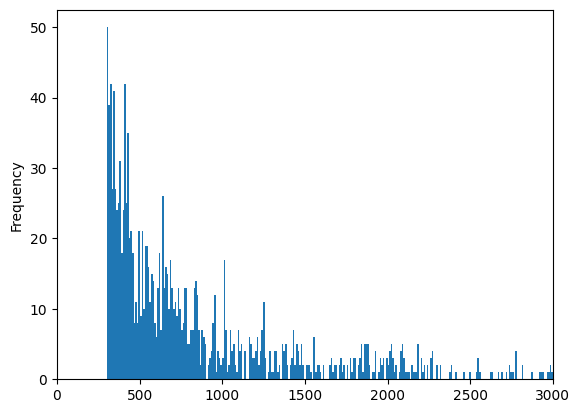

In [23]:
df.plot.hist(bins=1000, xlim=(0, 3000))

Trying to estimate the PDF of the lesion areas, with Gaussian kernel

Text(0.5, 1.0, 'Estimated PDF from Data Samples')

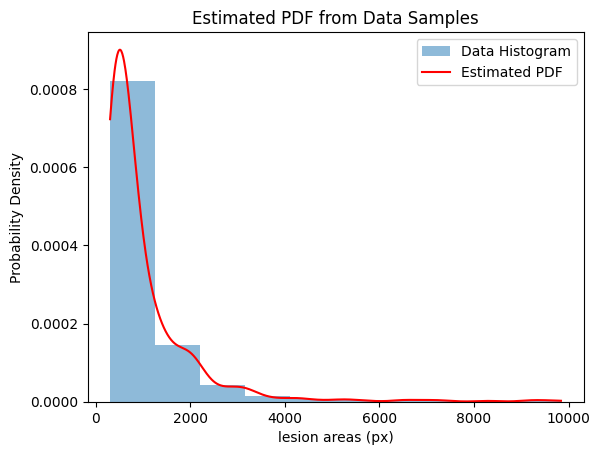

In [24]:
# Assuming your data is stored in a NumPy array called 'data_samples'
data_samples = np.array(lesion_areas)

# Create a kernel density estimate (KDE) from the data
kde = gaussian_kde(data_samples)

# Generate points along the x-axis for the PDF plot
x_vals = np.linspace(min(data_samples), max(data_samples), 1000)

# Evaluate the PDF at the specified points
pdf_values = kde(x_vals)

# Plot the original data and the estimated PDF
plt.hist(data_samples, density=True, alpha=0.5, label='Data Histogram')
plt.plot(x_vals, pdf_values, label='Estimated PDF', color='red')
plt.legend()
plt.xlabel('lesion areas (px)')
plt.ylabel('Probability Density')
plt.title('Estimated PDF from Data Samples')

In [25]:
num_samples = 450
# sample from the estimated density distribution
np.random.seed(42)
probabilities = pdf_values / np.sum(pdf_values)
drawn_indices = np.random.choice(len(x_vals), size=num_samples, replace=False, p=probabilities)
indices = np.array(lesion_indices)[drawn_indices]

In [26]:
df_drawn = pd.Series(np.array(lesion_areas)[indices], name="lesion_area")
df_drawn.plot.hist(bins=100)

IndexError: index 1564 is out of bounds for axis 0 with size 1526

Trying alternative kernel as suggested by Leo - the exponential kernel

Text(0.5, 1.0, 'Estimated PDF from Data Samples')

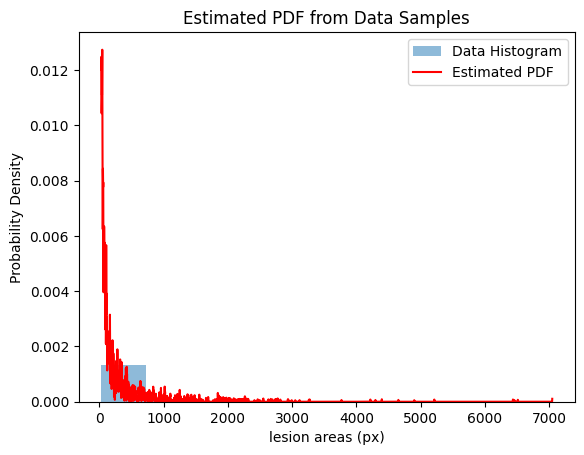

In [107]:
from sklearn.neighbors import KernelDensity
import numpy as np

data_samples = np.array([lesion_areas]).reshape(-1, 1)  # Your data samples

# Bandwidth parameter for the kernel density estimate
bandwidth = 1

# Create a KernelDensity estimator with the custom kernel
kde = KernelDensity(kernel='exponential', bandwidth=bandwidth)

# Fit the estimator to the data
kde.fit(data_samples)

# Evaluate the density model at specific points
x_vals = np.linspace(min(data_samples), max(data_samples), len(data_samples))
log_dens = kde.score_samples(x_vals)
pdf_values = np.exp(log_dens)

# Plot the original data and the estimated PDF
plt.hist(data_samples, density=True, alpha=0.5, label='Data Histogram')
plt.plot(x_vals, pdf_values, label='Estimated PDF', color='red')
plt.legend()
# plt.xlim(0,100)
plt.xlabel('lesion areas (px)')
plt.ylabel('Probability Density')
plt.title('Estimated PDF from Data Samples')

In [119]:
# Normalize densities to form a probability distribution
probabilities = pdf_values / np.sum(pdf_values)
x_vals = x_vals.reshape(-1, 1)

# Draw 500 samples from the estimated density distribution
np.random.seed(42)
drawn_indices = np.random.choice(len(x_vals), size=500, replace=False, p=probabilities)
drawn_samples = data_samples[drawn_indices]

<Axes: ylabel='Frequency'>

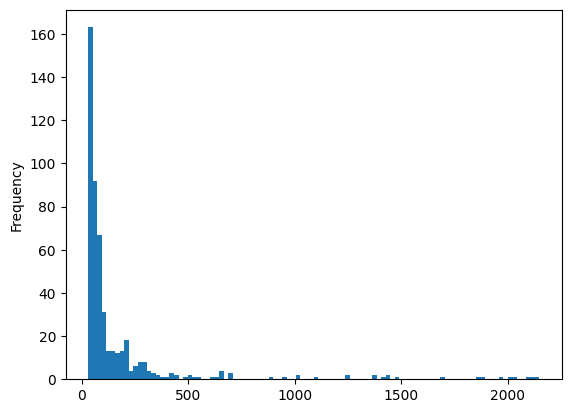

In [109]:
df_drawn = pd.Series(np.squeeze(drawn_samples), name="lesion_area")
df_drawn.plot.hist(bins=100)

For investigating the patches that were chosen, we will save the patches as images into debug folder

In [191]:
from tqdm import tqdm
from multiprocessing import Pool

def save_img(x):
    idx, chosen = x
    plt.imshow(np.squeeze(chosen.cpu().detach().numpy()))
    debug_path = "/cs/CASMIP/alina.ryabtsev/FewShotLearning/test_universeg/debug_patches"
    # save the chosen patches as a file in the debug path
    plt.savefig(os.path.join(debug_path, f"chosen_support_{idx}.png"))

chosen_support = support_labels_patches[np.array(lesion_indices)[drawn_indices]]
with Pool(os.cpu_count() - 2) as p:
    with tqdm(total=len(chosen_support)) as pbar:
            for _ in p.imap(save_img, zip(np.array(lesion_indices)[drawn_indices], chosen_support)):
                pbar.update()


100%|██████████| 450/450 [00:05<00:00, 86.90it/s]


In [26]:
# clear cuda cache if necessary
import gc
torch.cuda.empty_cache()
gc.collect()

257

In [28]:
logging.basicConfig(filename='liver_prediction_support_20.log', encoding='utf-8', level=logging.DEBUG,
                    format='%(asctime)s %(message)s', datefmt='%d/%m/%Y %I:%M:%S %p')
logging.info("Started running liver prediction")
model = universeg(pretrained=True)
_ = model.to(device)

In [29]:
@torch.no_grad()
def inference_with_slice_inferer(inferer: Inferer, model_inferer: Inferer, model: nn.Module, image: torch.Tensor,
                                 label: torch.Tensor, support_images: torch.Tensor,
                                 support_labels: torch.Tensor) -> dict:
    image, label = image.to(device), label.to(device)
    # inference with Monai's slice inference
    logits = inferer(image, model_inferer, model, support_images[None], support_labels[None])
    logits = torch.squeeze(logits)
    soft_pred = torch.sigmoid(logits)
    hard_pred = soft_pred.round().clip(0, 1)

    # return a dictionary of all relevant variables
    return {'Soft Prediction': soft_pred,
            'Prediction': hard_pred}


@torch.no_grad()
def model_patches_inferer(image: torch.Tensor, model: nn.Module, support_images_patches: torch.Tensor,
                          support_labels_patches) -> Inferer:
    patch_size = PATCH_SIZE
    splitter = SlidingWindowSplitter(patch_size=patch_size, overlap=0.5, device=device)
    patch_inferer = PatchInferer(splitter, batch_size=1, device=device)
    return patch_inferer(
        image.to(device), model, support_images_patches, support_labels_patches
    )

In [30]:
def preprocess_prediction(pred: torch.Tensor, seg_name: str, save: bool, save_name: str = "pred",
                          resize_scan: bool = True) -> np.ndarray:
    """
    This function gets a 3D scan and preprocess it to the nifti shape (W, H, D) and resizes it to 512*512*D
    :param pred: prediction of the model as a tensor
    :param seg_name: the filename of the corresponding segmentation file
    :param save: a boolean whether to save to not
    :param save_name: if saving the prediction, what is the filename of the prediction.
    :param resize_scan: a boolean whether to resize or not
    """
    pred = E.rearrange(pred, "D W H -> W H D")
    pred = pred.cpu().numpy()
    # pred = pred.astype(np.float64)
    pred = pred.astype(np.float32)
    if resize_scan:
        pred = resize(pred, (512, 512, pred.shape[2]), anti_aliasing=True)
    if save:
        pred_filename = seg_name.replace("seg", save_name)
        affine_nifti = nib.load(seg_name).affine
        nifti_to_save = nib.Nifti1Image(pred, affine_nifti)
        # nifti_to_save.header.set_data_dtype(np.unit16)
        nib.save(nifti_to_save, pred_filename)
    return pred

In [19]:
d_query = LiverTumorsDataset3D(split="query", support_frac=0.2, label=1, resize_scan=False)

100%|██████████| 83/83 [00:51<00:00,  1.61it/s]


In [ ]:
slice_inferer = SliceInferer(spatial_dim=0, roi_size=(512, 512), sw_batch_size=1, progress=True, device=device)
total = len(d_query)
selected_support_images_patches = torch.index_select(support_images_patches, 0, torch.tensor(indices).to(device))
selected_support_labels_patches = torch.index_select(support_labels_patches, 0, torch.tensor(indices).to(device))
with tqdm(total=total) as pbar:
    with logging_redirect_tqdm():
        for i, pack in enumerate(d_query):
            image, label, filename = pack
            image, label = image.to(device), label.to(device)
            print(f"Inferring on {filename[0]}")
            # inference with Monai's slice inference
            image = torch.unsqueeze(image, dim=1).to(device)
            res = inference_with_slice_inferer(slice_inferer, model_patches_inferer, model, image, label,
                                               selected_support_images_patches, selected_support_labels_patches)
            scan_name, seg_name = filename
            hard_pred = res["Prediction"]
            assert not torch.any(torch.isnan(hard_pred)), f"Prediction contains NaNs: {scan_name}"
            logging.info(f"finished inference of scan {i + 1}: {scan_name}")
            preprocess_prediction(hard_pred, seg_name, True, save_name=f"support_analysis", resize_scan=False)
            logging.info(f"finished postprocessing of prediction {i + 1}: {scan_name}")
            torch.cuda.empty_cache()
            gc.collect()
            pbar.update(1)


In [4]:
predictions_list = sorted(glob(os.path.join(LIVER_LESIONS_DATASET, "*support_analysis.nii.gz")))
gt_list = [p.replace("support_analysis.nii.gz", "seg.nii.gz") for p in predictions_list]
roi_list = [p.replace("support_analysis.nii.gz", "liver.nii.gz") for p in predictions_list]
calculate_measures("tumors", predictions_list, gt_list, range(1, 2), excel_path="./universeg_support_analysis.xlsx", roi_list=roi_list)

Calculating measures for threshold 1


100%|██████████| 83/83 [00:00<00:00, 68220.11it/s]


Writing measures for threshold 1 finished


## Running Support set with negative patches:
Now we would like to insert into the support set patches that do not contain any tumors, more precisely patches that are detected as FP when running support scans as query.

In [ ]:
def get_FP_patches(pred_filename, seg_filename, roi_filename, patch_size=(128, 128)):
    """
    This function gets a prediction and segmentation filenames and returns the patches that are FP.
    :param pred_filename: the filename of the prediction
    :param seg_filename: the filename of the segmentation
    :param roi_filename: the filename of the ROI
    :param patch_size: the size of the patches
    :return: a list of FP patches
    """
    pred = nib.load(pred_filename).get_fdata()
    seg = nib.load(seg_filename).get_fdata()
    roi = nib.load(roi_filename).get_fdata()
    roi = roi.astype(np.bool)
    pred = pred.astype(np.bool)
    seg = seg.astype(np.bool)
    FP = np.logical_and(pred, np.logical_not(seg))
    FP = np.logical_and(FP, roi)
    FP_patches = view_as_windows(FP, (patch_size[0], patch_size[1], 1), step=(64, 64, 1))

    # take positive patches from FP_patches
    FP_patches = np.concatenate(FP_patches, axis=0)
    FP_patches = np.concatenate(FP_patches, axis=0)
    # patches = np.array([x for x in FP_patches if np.any(x)])
    patches = FP_patches[get_positive_patches_idx(FP_patches)]
    return patches

In [32]:
# support-query
d_query = LiverTumorsDataset3D(split="query-support", support_frac=0.2, label=1, resize_scan=False)

100%|██████████| 20/20 [00:12<00:00,  1.57it/s]


In [33]:
slice_inferer = SliceInferer(spatial_dim=0, roi_size=(512, 512), sw_batch_size=1, progress=True, device=device)
total = len(d_query)
selected_support_images_patches = torch.index_select(support_images_patches, 0, torch.tensor(indices).to(device))
selected_support_labels_patches = torch.index_select(support_labels_patches, 0, torch.tensor(indices).to(device))
with tqdm(total=total) as pbar:
    with logging_redirect_tqdm():
        for i, pack in enumerate(d_query):
            image, label, filename = pack
            image, label = image.to(device), label.to(device)
            print(f"Inferring on {filename[0]}")
            # inference with Monai's slice inference
            image = torch.unsqueeze(image, dim=1).to(device)
            res = inference_with_slice_inferer(slice_inferer, model_patches_inferer, model, image, label,
                                               selected_support_images_patches, selected_support_labels_patches)
            scan_name, seg_name = filename
            hard_pred = res["Prediction"]
            assert not torch.any(torch.isnan(hard_pred)), f"Prediction contains NaNs: {scan_name}"
            logging.info(f"finished inference of scan {i + 1}: {scan_name}")
            preprocess_prediction(hard_pred, seg_name, True, save_name=f"support_FP_analysis", resize_scan=False)
            logging.info(f"finished postprocessing of prediction {i + 1}: {scan_name}")
            torch.cuda.empty_cache()
            gc.collect()
            pbar.update(1)

  0%|          | 0/20 [00:00<?, ?it/s]

Inferring on /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/A_Aa_03_10_2019_scan.nii.gz



100%|██████████| 52/52 [05:49<00:00,  6.73s/it]
finished inference of scan 1: /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/A_Aa_03_10_2019_scan.nii.gz
finished postprocessing of prediction 1: /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/A_Aa_03_10_2019_scan.nii.gz
  5%|▌         | 1/20 [05:50<1:50:51, 350.09s/it]

Inferring on /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/C_R_A_27_07_2018_scan.nii.gz



100%|██████████| 53/53 [05:44<00:00,  6.51s/it]
finished inference of scan 2: /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/C_R_A_27_07_2018_scan.nii.gz
finished postprocessing of prediction 2: /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/C_R_A_27_07_2018_scan.nii.gz
 10%|█         | 2/20 [11:35<1:44:09, 347.17s/it]

...


100%|██████████| 58/58 [05:52<00:00,  6.08s/it]
finished inference of scan 18: /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/S_M_Y_05_04_2020_scan.nii.gz
finished postprocessing of prediction 18: /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/S_M_Y_05_04_2020_scan.nii.gz
 90%|█████████ | 18/20 [2:14:16<13:40, 410.36s/it]

Inferring on /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/S_I_16_03_2020_scan.nii.gz



100%|██████████| 55/55 [05:54<00:00,  6.45s/it]
finished inference of scan 19: /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/S_I_16_03_2020_scan.nii.gz
finished postprocessing of prediction 19: /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/S_I_16_03_2020_scan.nii.gz
 95%|█████████▌| 19/20 [2:20:12<06:33, 393.83s/it]

Inferring on /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/A_D_04_11_2019_scan.nii.gz



100%|██████████| 61/61 [06:24<00:00,  6.31s/it]
finished inference of scan 20: /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/A_D_04_11_2019_scan.nii.gz
finished postprocessing of prediction 20: /cs/casmip/alina.ryabtsev/FewShotLearning/datasets/liver_lesions/A_D_04_11_2019_scan.nii.gz
100%|██████████| 20/20 [2:26:37<00:00, 439.86s/it]


Calculating measures for running universeg query predictions with the support set with FP patches:

In [4]:
predictions_list = sorted(glob(os.path.join(LIVER_LESIONS_DATASET, "*support_analysis_with_FP.nii.gz")))
gt_list = [p.replace("support_analysis_with_FP.nii.gz", "seg.nii.gz") for p in predictions_list]
roi_list = [p.replace("support_analysis_with_FP.nii.gz", "liver.nii.gz") for p in predictions_list]
calculate_measures("tumors", predictions_list, gt_list, range(1, 2), excel_path="./universeg_support_analysis_with_FP.xlsx", roi_list=roi_list)

Calculating measures for threshold 1


100%|██████████| 83/83 [00:00<00:00, 73243.68it/s]


Writing measures for threshold 1 finished


In [136]:
predictions_list = sorted(glob(os.path.join(LIVER_LESIONS_DATASET, "*support_analysis_exp_kernel.nii.gz")))
gt_list = [p.replace("support_analysis_exp_kernel.nii.gz", "seg.nii.gz") for p in predictions_list]
roi_list = [p.replace("support_analysis_exp_kernel.nii.gz", "liver.nii.gz") for p in predictions_list]
calculate_measures("tumors", predictions_list, gt_list, range(1, 2), excel_path="./universeg_support_analysis_exp_kernel.xlsx", roi_list=roi_list)

Calculating measures for threshold 1


100%|██████████| 83/83 [00:00<00:00, 63284.35it/s]


Writing measures for threshold 1 finished


In [2]:
predictions_list = sorted(glob(os.path.join(LIVER_LESIONS_DATASET, "*support_analysis_big_lesions.nii.gz")))
gt_list = [p.replace("support_analysis_big_lesions.nii.gz", "seg.nii.gz") for p in predictions_list]
roi_list = [p.replace("support_analysis_big_lesions.nii.gz", "liver.nii.gz") for p in predictions_list]
calculate_measures("tumors", predictions_list, gt_list, range(1, 2), excel_path="./universeg_support_analysis_big_lesions.xlsx", roi_list=roi_list)

Calculating measures for threshold 1


100%|██████████| 83/83 [00:00<00:00, 78779.64it/s]


Writing measures for threshold 1 finished


In [30]:
predictions_list = sorted(glob(os.path.join(LIVER_LESIONS_DATASET, "*_support_analysis_10.nii.gz")))
gt_list = [p.replace("support_analysis_10.nii.gz", "seg.nii.gz") for p in predictions_list]
roi_list = [p.replace("support_analysis_10.nii.gz", "liver.nii.gz") for p in predictions_list]
calculate_measures("tumors", predictions_list, gt_list, range(1, 2), excel_path="./support_analysis_K10.xlsx", roi_list=roi_list)

Calculating measures for threshold 1


100%|██████████| 83/83 [00:00<00:00, 53206.06it/s]


Writing measures for threshold 1 finished
